### Importing Libraries

In [27]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

### a) Loading the Iris Dataset, Standardizing it and converting into Tensors.

In [ ]:
iris = load_iris()
X = iris.data[:,:2]   
y = iris.target    

print(set(y))
print(X.shape)

X_train,X_test,y_train,y_test=train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

X_train=torch.tensor(X_train, dtype=torch.float32)
y_train=torch.tensor(y_train, dtype=torch.long)

X_test=torch.tensor(X_test, dtype=torch.float32)
y_test=torch.tensor(y_test, dtype=torch.long)

{0, 1, 2}
(150, 2)


### b) Multi-class Perceptron implementation 

In [29]:
class MultiClassPerceptron:
    def __init__(self, n_features, n_classes, lr=0.01):
        self.W = torch.zeros(n_classes, n_features)
        self.b = torch.zeros(n_classes)
        self.lr = lr

    def predict(self, X):
        scores = X @ self.W.T + self.b
        return torch.argmax(scores, dim=1)

    def train_epoch(self, X, y):
        for i in range(X.shape[0]):
            x_i = X[i]
            y_true = y[i]

            scores = self.W @ x_i + self.b
            y_pred = torch.argmax(scores)

            if y_pred != y_true:
                self.W[y_true] += self.lr * x_i
                self.b[y_true] += self.lr
                self.W[y_pred] -= self.lr * x_i
                self.b[y_pred] -= self.lr


### c) Training the Perceptron for different iterations and comparing their accuracies.

In [36]:
iterations_list = [10, 50, 100, 200]

train_acc = []
test_acc = []
models = {}

for iters in iterations_list:
    model = MultiClassPerceptron(
        n_features=2,
        n_classes=3,
        lr=0.01
    )

    for _ in range(iters):
        model.train_epoch(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc.append(accuracy_score(y_train, y_train_pred))
    test_acc.append(accuracy_score(y_test, y_test_pred))

    models[iters] = model
    print(train_acc)
    print(test_acc)


[0.8380952380952381]
[0.6444444444444445]
[0.8380952380952381, 0.8380952380952381]
[0.6444444444444445, 0.7777777777777778]
[0.8380952380952381, 0.8380952380952381, 0.7714285714285715]
[0.6444444444444445, 0.7777777777777778, 0.6444444444444445]
[0.8380952380952381, 0.8380952380952381, 0.7714285714285715, 0.7714285714285715]
[0.6444444444444445, 0.7777777777777778, 0.6444444444444445, 0.6444444444444445]


### d) Visualizing the accuracies vs iterations and plotting the decission boundaries.

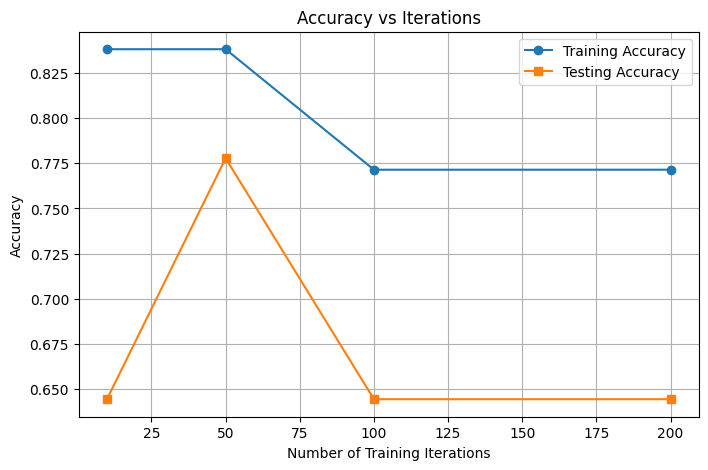

In [37]:
plt.figure(figsize=(8,5))
plt.plot(iterations_list, train_acc, marker='o', label="Training Accuracy")
plt.plot(iterations_list, test_acc, marker='s', label="Testing Accuracy")
plt.xlabel("Number of Training Iterations")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Iterations")
plt.legend()
plt.grid()
plt.show()


In [32]:
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
    y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = torch.tensor(
        np.c_[xx.ravel(), yy.ravel()],
        dtype=torch.float32
    )

    Z = model.predict(grid).numpy()
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y, edgecolor='k')
    plt.title(title)
    plt.show()


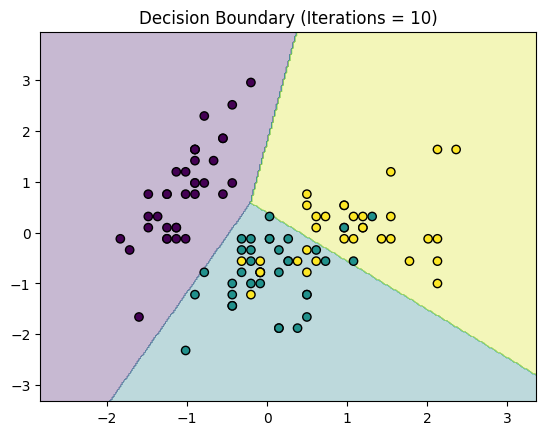

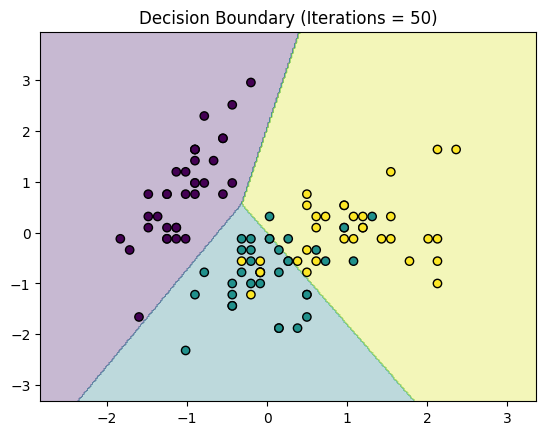

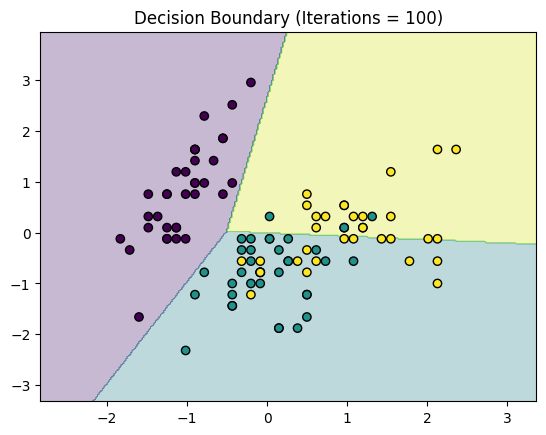

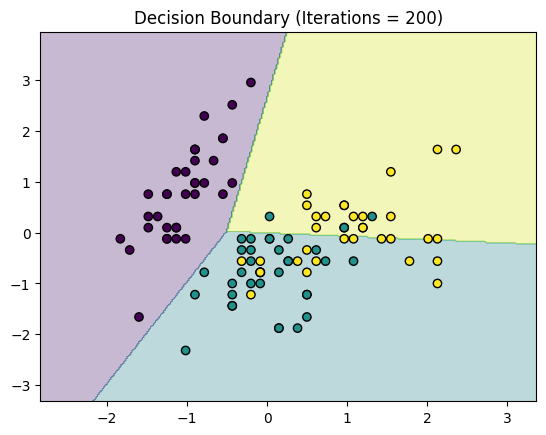

In [33]:
for iters in iterations_list:
    plot_decision_boundary(
        models[iters],
        X_train.numpy(),
        y_train.numpy(),
        f"Decision Boundary (Iterations = {iters})"
    )


### e) Limitations and Improvements which can be made in Report